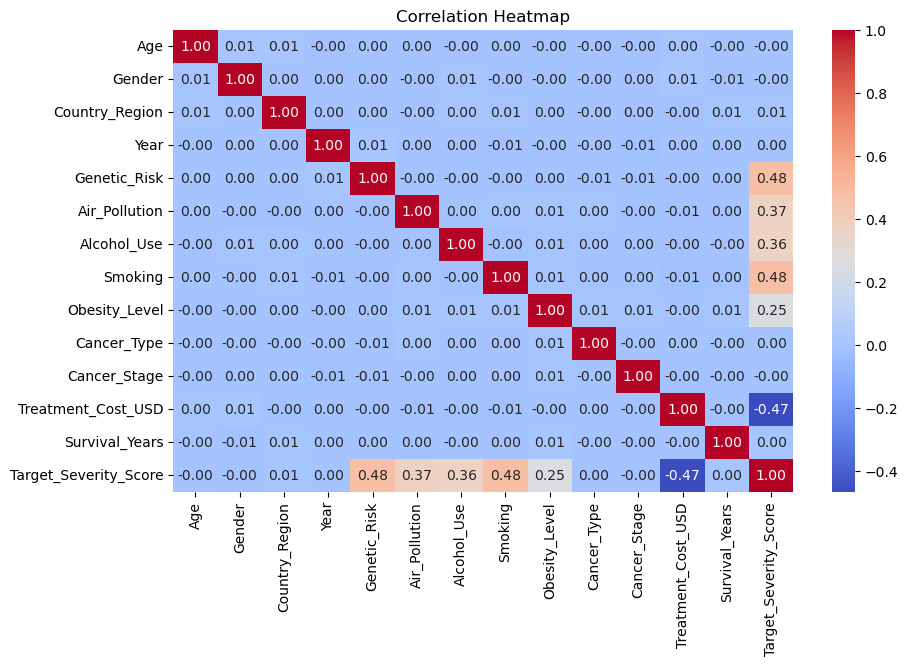

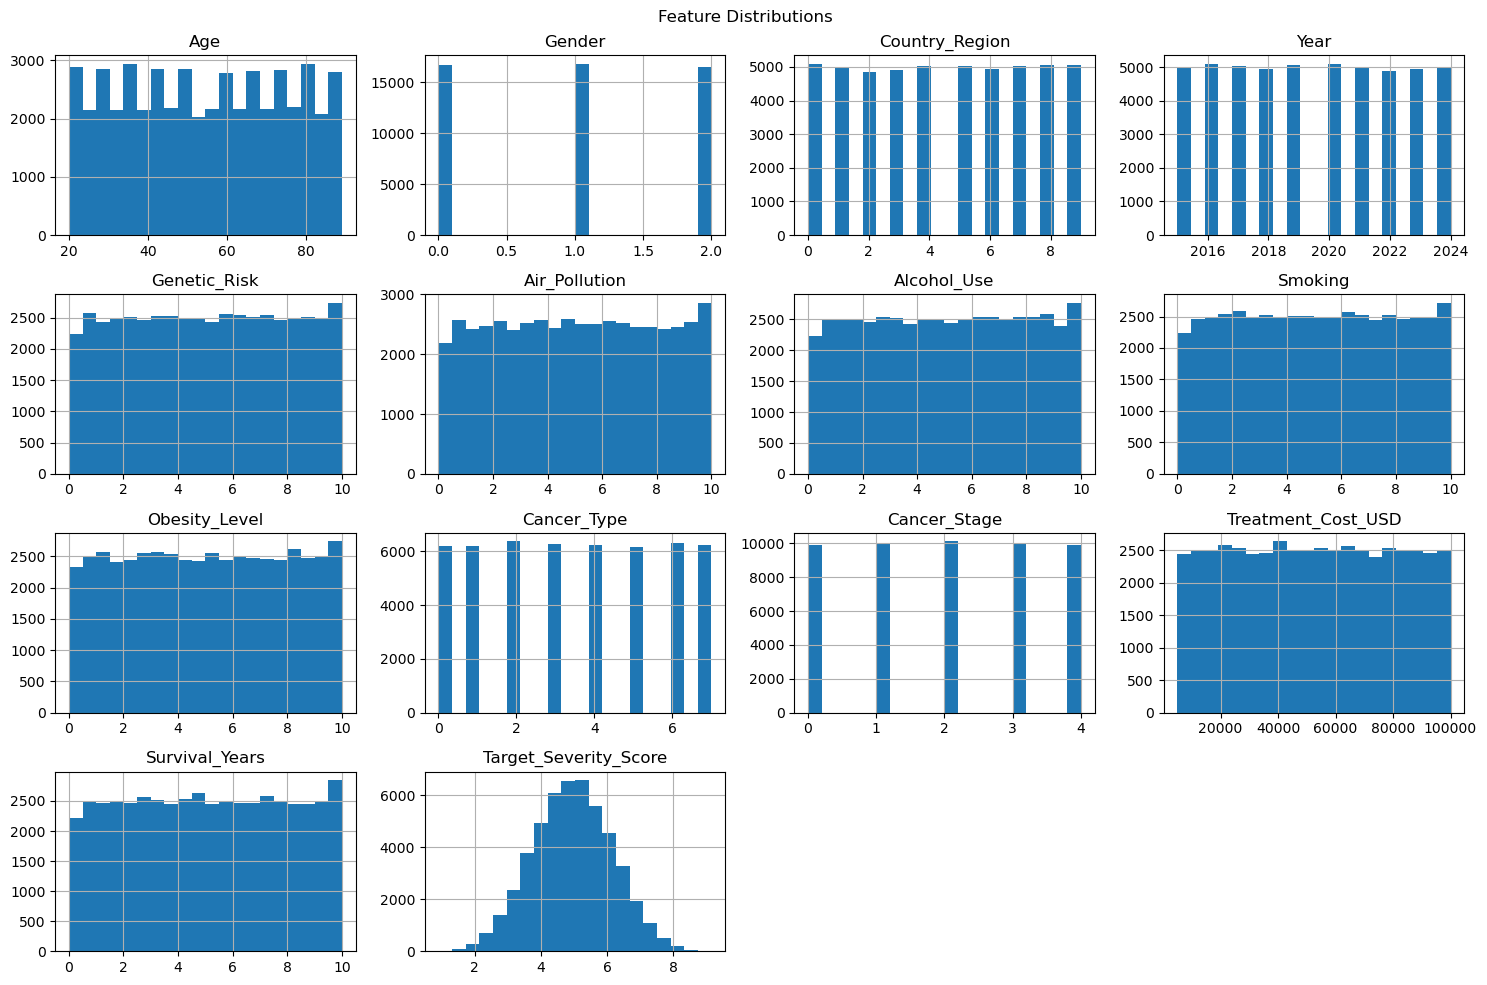

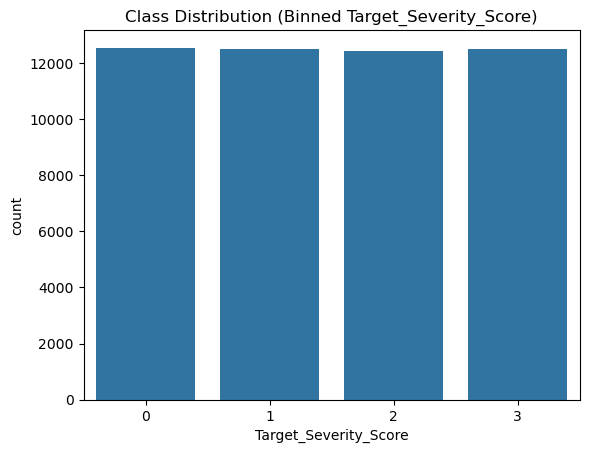

Best k: 20
Accuracy: 0.7558
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86      2516
           1       0.66      0.66      0.66      2551
           2       0.65      0.67      0.66      2470
           3       0.89      0.82      0.85      2463

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000

Confusion Matrix:
 [[2194  318    4    0]
 [ 404 1695  450    2]
 [   4  567 1650  249]
 [   0    6  438 2019]]


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Load dataset
df = pd.read_csv("global_cancer_patients_2015_2024.csv")
# Drop non-informative ID column
df = df.drop(columns=["Patient_ID"])
# Encode categorical features
label_encoders = {}
categorical_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
# Split features and target
X = df.drop(columns=['Target_Severity_Score'])
y = df['Target_Severity_Score']
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# EDA - Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# EDA - Histograms
df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()
# Bin target for classification
y_binned = pd.qcut(y, q=4, labels=False)
# Class distribution
sns.countplot(x=y_binned)
plt.title("Class Distribution (Binned Target_Severity_Score)")
plt.show()
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binned, test_size=0.2, random_state=42)
# Hyperparameter tuning for KNN
param_grid = {'n_neighbors': list(range(1, 21))}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)
# Best KNN model
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Best k:", grid_search.best_params_['n_neighbors'])
print("Accuracy:", accuracy)
print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Class labels
labels = [0, 1, 2, 3]

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_simple, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Extract precision, recall, f1-score per class from report
precision = [report_simple[str(i)]['precision'] for i in labels]
recall = [report_simple[str(i)]['recall'] for i in labels]
f1_score = [report_simple[str(i)]['f1-score'] for i in labels]

# Bar Plot for Precision, Recall, and F1-Score
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-Score')

plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Classification Metrics per Class')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()
